In [1]:
# data refactor:
# rename to same ep it format
# remove copied_from.json
# remove pwmetrics/avgloss, pwmetrics/ent, and ckptmetrics/ent as they were calculated wrong
# remove epoch 0 ckptmetrics

# notes:
# anything with the same name in gradmetrics and ckptmetrics is the same
# loss in pwmetrics is really a ckptmetric (saved once per epoch)

In [2]:
from data_utils import *


DATA_ROOT = "../outputs/combined/"
FIGURE_ROOT = Path("../outputs/plots/var_epoch")
N_RUNS = 100
N_EXAMPLES = 50000

model_df = get_model_df(DATA_ROOT)
MODEL_SUBSET = [
    {"key": "lottery_8ae667adac9b690a88b522e85f1388c8"},
    {"key": "lottery_cf40a5a8bbe4f285b8fe317c1aa95dd5"},
    {"key": "lottery_06562e05cda1bf840ee146490815ed82"},
    {"key": "lottery_9dc2b8dfff54c4da57570d7b391dcccd"},
]
model_df = multi_filter_df(model_df, MODEL_SUBSET)
model_df

/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,model_key,dataset_key,Model,Dataset,Task,Parameters,path,key,n_replicates
5,cifar_resnet_20,cifar10,ResNet-20,CIFAR-10,CIFAR-10/ResNet-20,272474,../outputs/combined/lottery_8ae667adac9b690a88...,lottery_8ae667adac9b690a88b522e85f1388c8,100
8,cifar_vgg_16,cifar10,VGG-16,CIFAR-10,CIFAR-10/VGG-16,14728266,../outputs/combined/lottery_cf40a5a8bbe4f285b8...,lottery_cf40a5a8bbe4f285b8fe317c1aa95dd5,100
1,cifar_vgg_16,cifar100,VGG-16,CIFAR-100,CIFAR-100/VGG-16,14728266,../outputs/combined/lottery_06562e05cda1bf840e...,lottery_06562e05cda1bf840ee146490815ed82,100
6,cifar_resnet_20,cifar100,ResNet-20,CIFAR-100,CIFAR-100/ResNet-20,272474,../outputs/combined/lottery_9dc2b8dfff54c4da57...,lottery_9dc2b8dfff54c4da57570d7b391dcccd,100


In [3]:
from itertools import product


def plot_training_time_correlations(df, keys, row_ep=[10, 150], col_ep=[20, 160], name=None):
    fig, axes = plt.subplots(len(keys) // 2, 2, figsize=(4, len(keys)))
    ep_df = df[(df["Method"] == "One Step") & (df["Epoch"].isin([10, 20, 150, 160]))]
    avg_df = df[(df["Method"] == "Training") & (df["Type"] == "")]
    for key, ax in zip(keys, axes.flatten()):
        sub_df = filter_df(ep_df, {"key": key})
        values_r = get_single_epochs(sub_df, row_ep)
        values_c = get_single_epochs(sub_df, col_ep)
        labels_r = [f"{x}ep" for x in row_ep]
        labels_c = [f"{x}ep" for x in col_ep]

        all_score = filter_df(avg_df, {"key": key})
        if len(all_score) == 1:
            all_value = np.expand_dims(all_score.iloc[0]["array"], 0)
        else:
            all_value = np.full_like(values_c[:1], np.nan)

        values_c = np.concatenate([values_c, all_value], axis=0)
        labels_c = labels_c + ["Mean"]

        matrix = corr_matrix(values_r, values_c)
        plot_corr_matrix(matrix, sub_df.iloc[0]["Short Name"], "", labels_r, "", labels_c, ax=ax)
    save_fig(FIGURE_ROOT, "rank_corr", name)


def plot_rank_error(df, keys, epochs=[10, 160], name=None):
    step_df = df[(df["Method"] == "One Step") & (df["Epoch"].isin(epochs))]
    avg_df = df[(df["Method"] == "Training") & (df["Type"] == "")]
    new_df = []
    for key in keys:
        ref_row = filter_df(avg_df, {"key": key})
        if len(ref_row) != 1:
            continue
        reference = ref_row.iloc[0]["array"]
        steps = filter_df(step_df, {"key": key})
        for _, row in steps.iterrows():
            values = row["array"]
            rank_err = get_rank_err(values, reference)
            new_df.append({
                "Score": row["Short Name"],
                "Sample Time": f"{row['Epoch']}ep",
                "Rank Error": rank_err.flatten(),
            })

    new_df = pd.DataFrame(new_df)
    new_df = new_df.explode("Rank Error")
    sns.boxplot(data=new_df, x="Rank Error", y="Score", hue="Sample Time", showfliers=False)
    save_fig(FIGURE_ROOT, "rank_err", name, figsize=(7, len(keys) / 1.5))


# subsample over epochs and compare scores with all
def plot_subsample_loss_rank_err(df, subsamples=[2, 4, 8, 16, 40, 80], n_iters=30, name=None):
    mean_loss = get_mean_training_score(df, "loss")
    losses = df[(df["Method"] == "One Step") & (df["key"] == "loss")]
    new_df = []
    for n_samples, randomize, _ in product(subsamples, [False, True], range(n_iters)):
        loss = subsample_epochs(losses, n_samples, randomize)
        loss = np.mean(loss, axis=0)
        new_df.append({
            "Epochs Sampled ($m$)": n_samples,
            "Method": "Random" if randomize else "Periodic",
            "Median Rank Error": np.median(get_rank_err(loss, mean_loss)),
        })
    ax = sns.lineplot(data=pd.DataFrame(new_df), x="Epochs Sampled ($m$)", y="Median Rank Error", hue="Method")
    ax.set_ylim(0, ax.get_ylim()[1])
    ax.plot(np.linspace(1, 80, 80), 0.22 / np.sqrt(np.linspace(1, 80, 80)), linestyle="dotted", label="$O(m^{-2})$", color="grey")
    ax.legend()
    save_fig(FIGURE_ROOT, "subsample_loss_rank_err", name=name)


def plot_training_time_loss_std(df, subset_size=20, name=None):
    losses = df[(df["Method"] == "One Step") & (df["key"] == "loss")]
    new_df = []
    for start in range(1, 161, subset_size):
        subset = get_single_epochs(losses, list(range(start, start + subset_size)))
        # std over subset of epochs, mean over replicates
        stds = np.mean(np.std(subset, axis=0), axis=0)
        new_df.append({
            f"Epoch ({subset_size}ep Per Bin)": start + subset_size - 1,
            "St. Dev.": stds,
        })

    new_df = pd.DataFrame(new_df)
    new_df = new_df.explode("St. Dev.")
    sns.boxplot(data=new_df, x=f"Epoch ({subset_size}ep Per Bin)", y="St. Dev.", showfliers=False)
    save_fig(FIGURE_ROOT, "loss_std", name=name)


def plot_training_time_all_loss_rank_err(df, epochs=list(range(1, 161)), name=None):
    mean_loss = get_mean_training_score(df, "loss")
    losses = get_single_epochs(df[(df["Method"] == "One Step") & (df["key"] == "loss")], epochs)
    new_df = []
    for epoch, loss in zip(epochs, losses):
        new_df.append({
            "Epoch": epoch,
            "$1 - \\rho$": 1 - get_corr(loss, mean_loss),
            "Rank Error": np.median(get_rank_err(loss, mean_loss).flatten()),
        })
    new_df = pd.DataFrame(new_df)
    new_df = new_df.explode("Rank Error")
    sns.lineplot(data=new_df, x="Epoch", y="$1 - \\rho$", label="$1 - \\rho$")
    ax = sns.lineplot(data=new_df, x="Epoch", y="Rank Error", label="Median Rank Error")
    ax.set_ylim(0, ax.get_ylim()[1])
    save_fig(FIGURE_ROOT, "loss_rank_err", name=name)


def plot_training_time_all_loss_corr(df, epochs=list(range(1, 161)), name=None):
    losses = get_single_epochs(df[(df["Method"] == "One Step") & (df["key"] == "loss")], epochs)
    corr = corr_matrix(losses)
    plt.imshow(corr)
    save_fig(FIGURE_ROOT, "loss_rank_corr", name=name, figsize=(8, 8))


def plot_forgetting_corr(df, name=None):
    batchforget = df[df["key"].apply(lambda x: x.startswith("batch_"))]
    matrix = []
    for _, row in batchforget.iterrows():
        epforget = filter_df(df, {"key": row["key"].split("_")[1]})
        assert len(epforget) == 1
        epforget = epforget.iloc[0]["array"]
        corr = get_corr(row["array"], epforget)
        matrix.append(corr)
    plot_corr_matrix(np.array(matrix).reshape(-1, 1), "", "", list(batchforget["Short Name"]), "", ["Batch vs Epoch $\\rho$"])
    save_fig(FIGURE_ROOT, "forget_rank_corr", name=name)

In [4]:
SELECTED_SCORES = [
    "loss",
    "acc",
    "margin",
    "el2n",
    "pd",
    "selfproto",
]

ALL_SCORES = [
    "loss",
    "acc",
    "margin",
    "conf",
    "maxconf",
    "el2n",
    "grand",
    "pd",
    "proto",
    "selfproto",
]

model_key                                         cifar_resnet_20
dataset_key                                               cifar10
Model                                                   ResNet-20
Dataset                                                  CIFAR-10
Task                                           CIFAR-10/ResNet-20
Parameters                                                 272474
path            ../outputs/combined/lottery_8ae667adac9b690a88...
key                      lottery_8ae667adac9b690a88b522e85f1388c8
n_replicates                                                  100
Name: 5, dtype: object


/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/scipy/stats/stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


Saving figure to ../outputs/plots/var_epoch/CIFAR-10-ResNet-20_selected_rank_corr.pdf


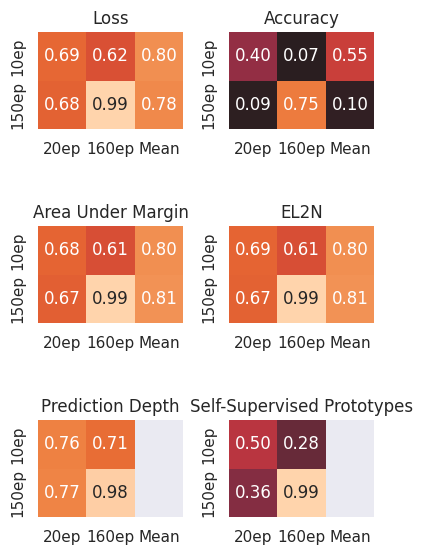

/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/scipy/stats/stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


Saving figure to ../outputs/plots/var_epoch/CIFAR-10-ResNet-20_rank_corr.pdf


<Figure size 640x480 with 0 Axes>

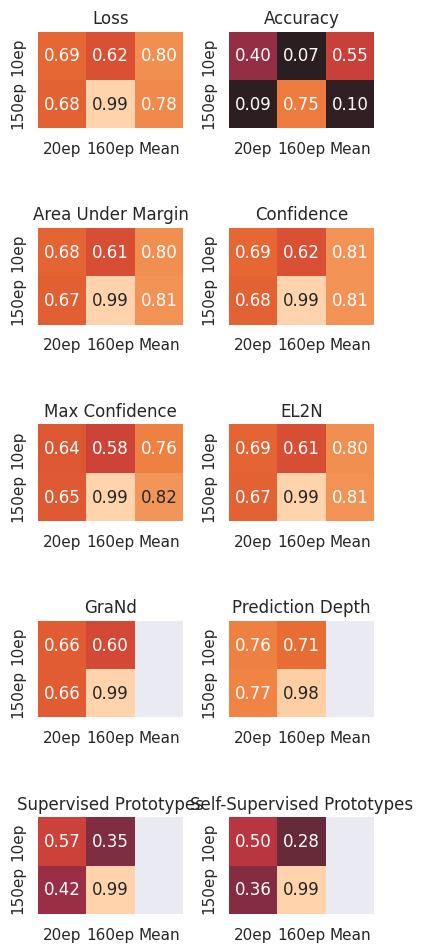

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-ResNet-20_selected_rank_err.pdf


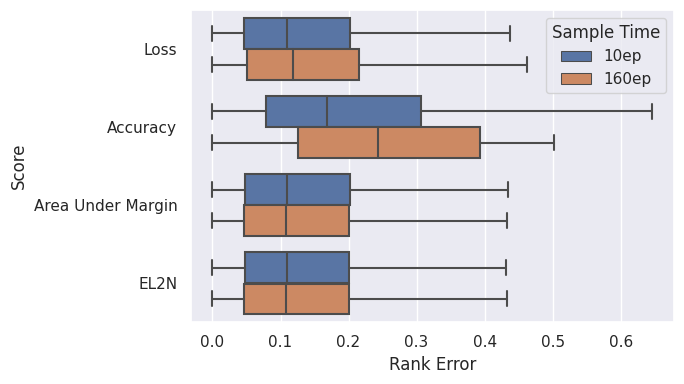

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-ResNet-20_rank_err.pdf


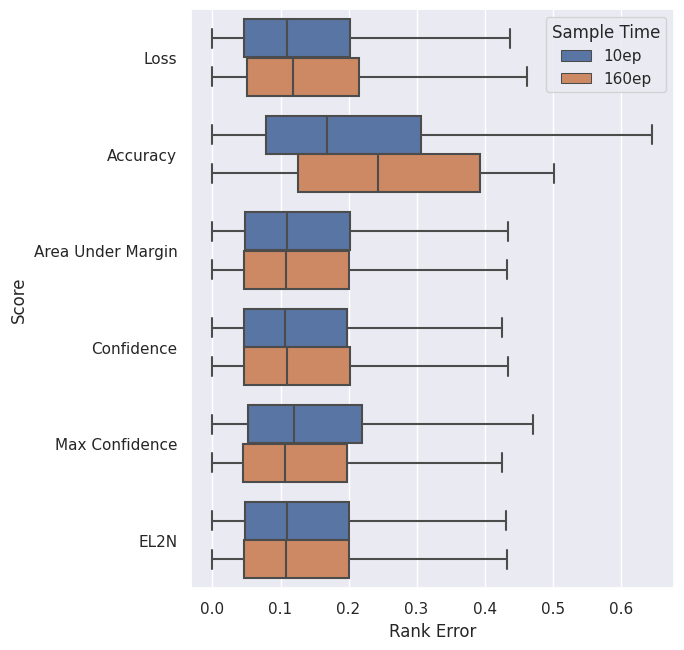

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-ResNet-20_subsample_loss_rank_err.pdf


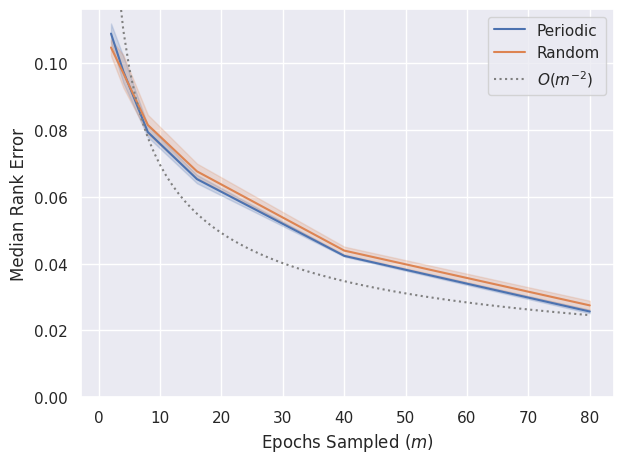

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-ResNet-20_loss_std.pdf


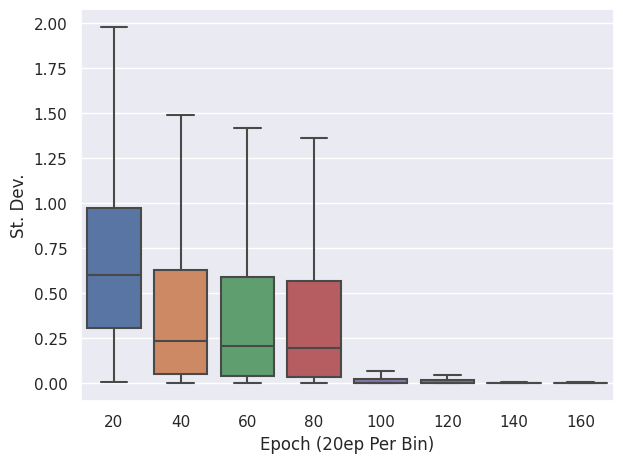

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-ResNet-20_loss_rank_err.pdf


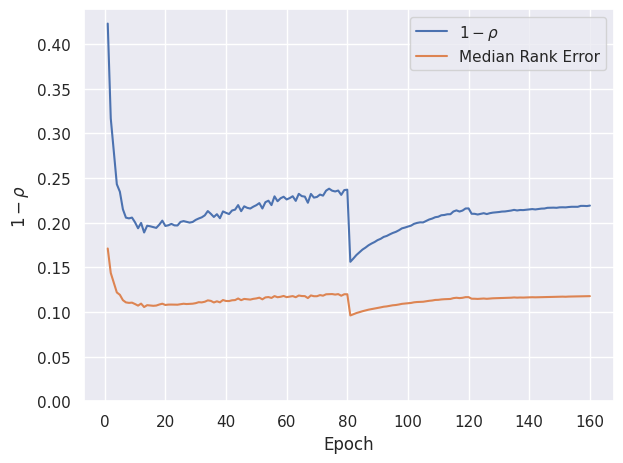

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-ResNet-20_forget_rank_corr.pdf


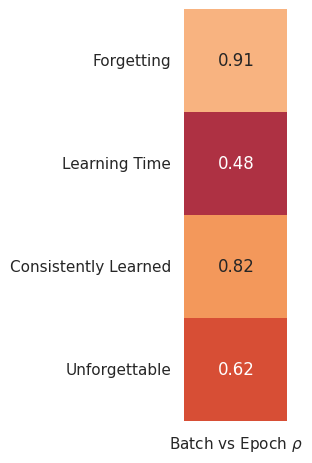

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-ResNet-20_loss_rank_corr.pdf


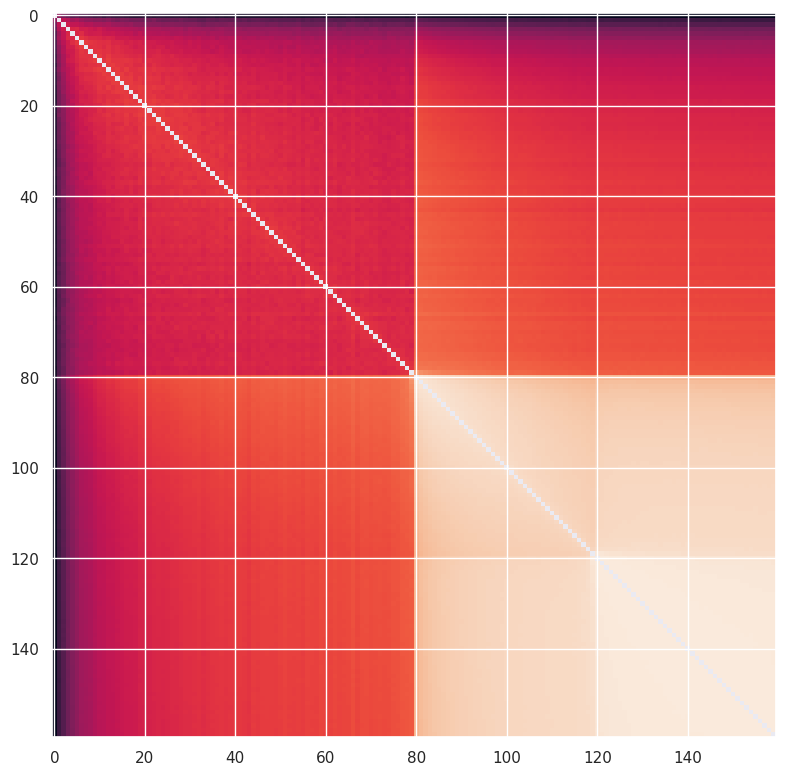

model_key                                            cifar_vgg_16
dataset_key                                               cifar10
Model                                                      VGG-16
Dataset                                                  CIFAR-10
Task                                              CIFAR-10/VGG-16
Parameters                                               14728266
path            ../outputs/combined/lottery_cf40a5a8bbe4f285b8...
key                      lottery_cf40a5a8bbe4f285b8fe317c1aa95dd5
n_replicates                                                  100
Name: 8, dtype: object


/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/scipy/stats/stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


Saving figure to ../outputs/plots/var_epoch/CIFAR-10-VGG-16_selected_rank_corr.pdf


<Figure size 640x480 with 0 Axes>

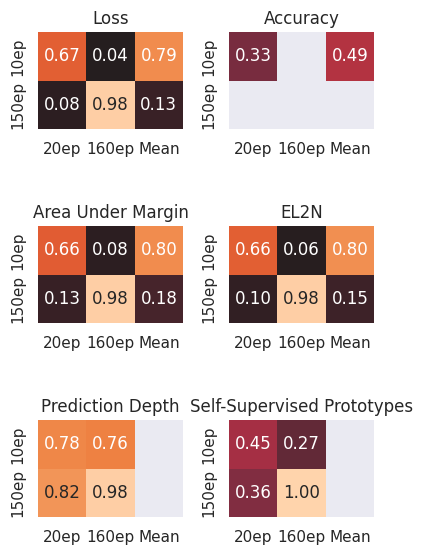

/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/scipy/stats/stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


Saving figure to ../outputs/plots/var_epoch/CIFAR-10-VGG-16_rank_corr.pdf


<Figure size 640x480 with 0 Axes>

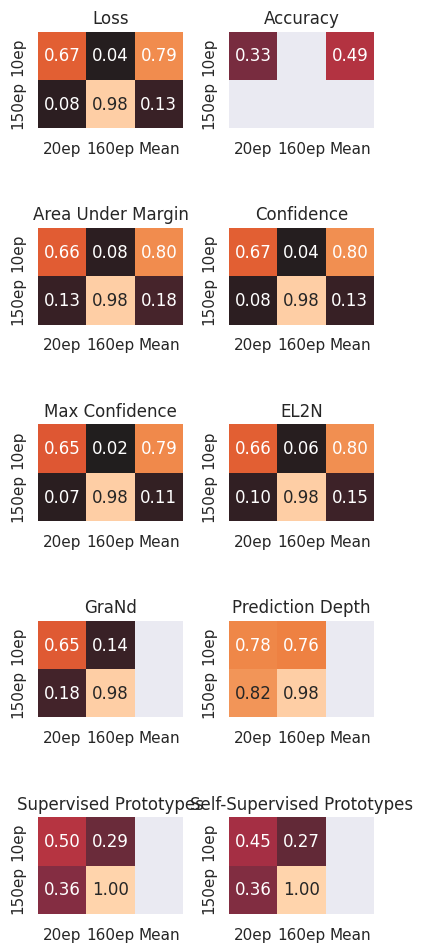

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-VGG-16_selected_rank_err.pdf


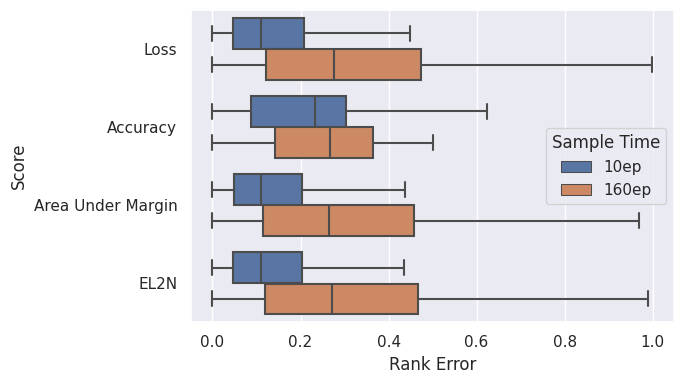

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-VGG-16_rank_err.pdf


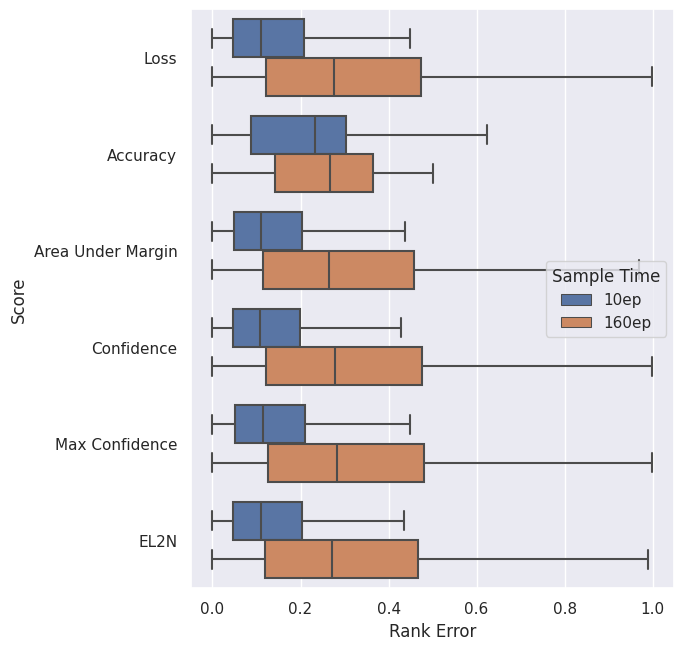

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-VGG-16_subsample_loss_rank_err.pdf


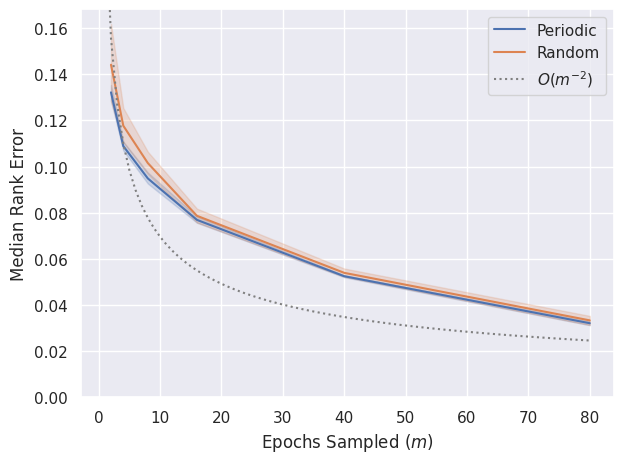

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-VGG-16_loss_std.pdf


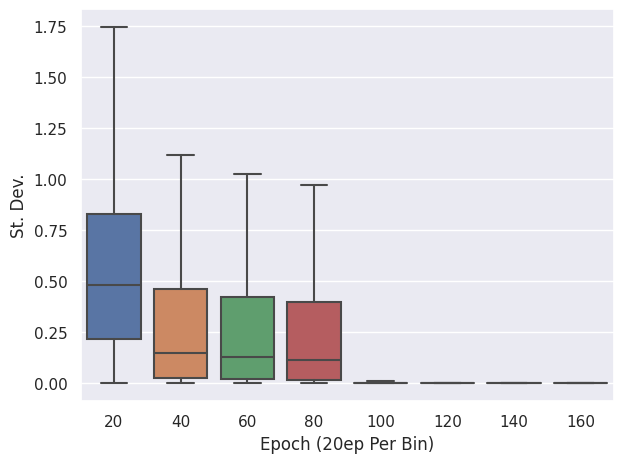

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-VGG-16_loss_rank_err.pdf


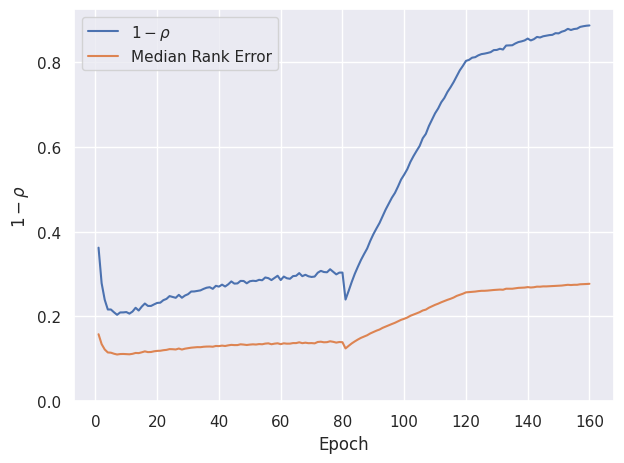

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-VGG-16_forget_rank_corr.pdf


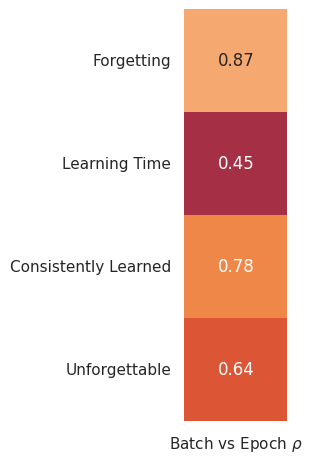

Saving figure to ../outputs/plots/var_epoch/CIFAR-10-VGG-16_loss_rank_corr.pdf


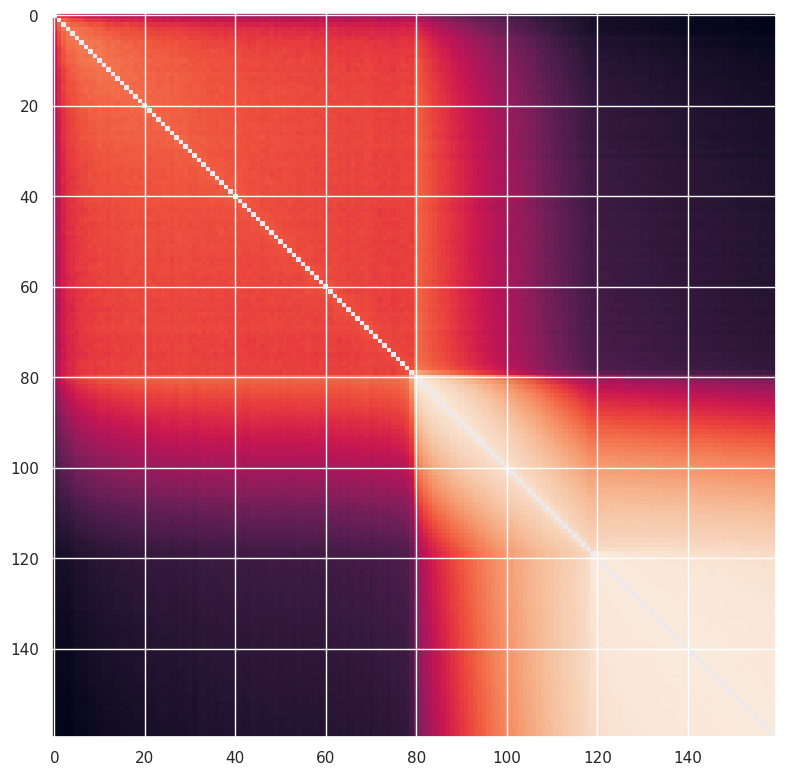

model_key                                            cifar_vgg_16
dataset_key                                              cifar100
Model                                                      VGG-16
Dataset                                                 CIFAR-100
Task                                             CIFAR-100/VGG-16
Parameters                                               14728266
path            ../outputs/combined/lottery_06562e05cda1bf840e...
key                      lottery_06562e05cda1bf840ee146490815ed82
n_replicates                                                  100
Name: 1, dtype: object
Grad and ckpt scores differ for ../outputs/combined/lottery_06562e05cda1bf840ee146490815ed82/replicate_100/level_0/main/gradmetrics/grand_20ep0it.npz: n=250, atol %=0.01470849338407377
Grad and ckpt scores differ for ../outputs/combined/lottery_06562e05cda1bf840ee146490815ed82/replicate_43/level_0/main/gradmetrics/grand_20ep0it.npz: n=270, atol %=0.01612396276328777
Grad and ckpt 

/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/scipy/stats/stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


Saving figure to ../outputs/plots/var_epoch/CIFAR-100-VGG-16_selected_rank_corr.pdf


<Figure size 640x480 with 0 Axes>

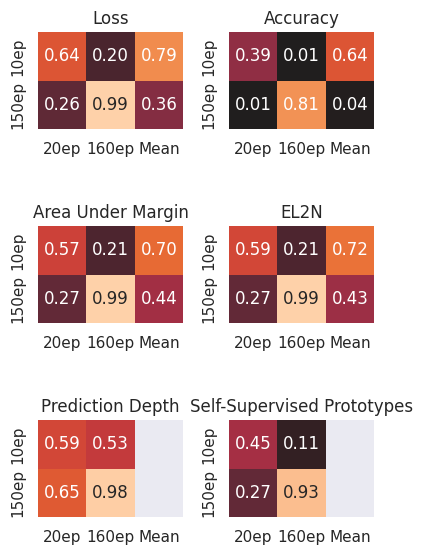

/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/scipy/stats/stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


Saving figure to ../outputs/plots/var_epoch/CIFAR-100-VGG-16_rank_corr.pdf


<Figure size 640x480 with 0 Axes>

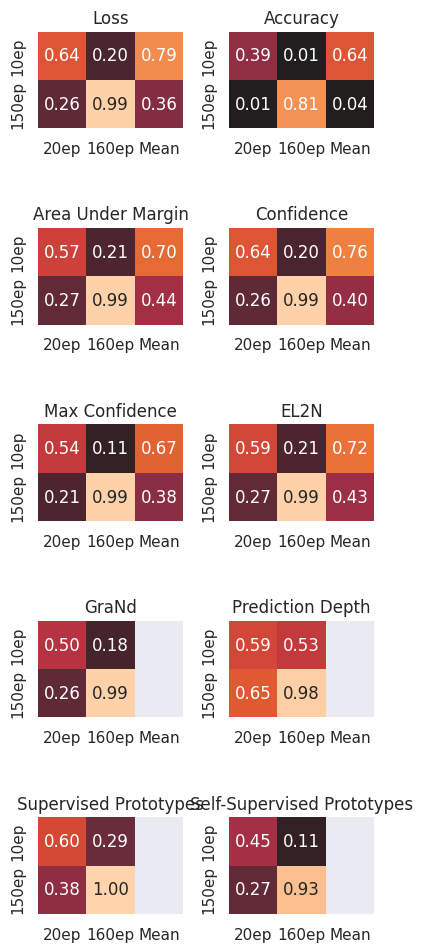

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-VGG-16_selected_rank_err.pdf


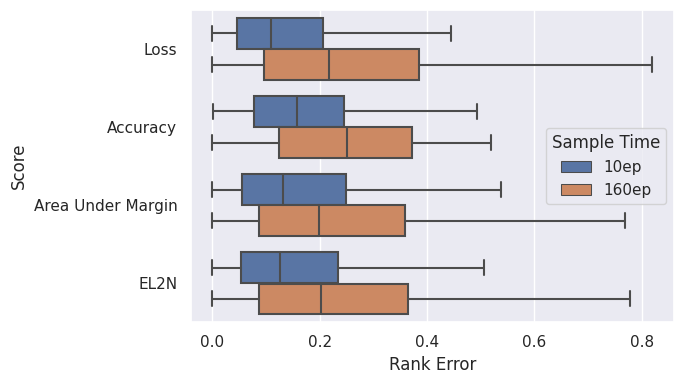

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-VGG-16_rank_err.pdf


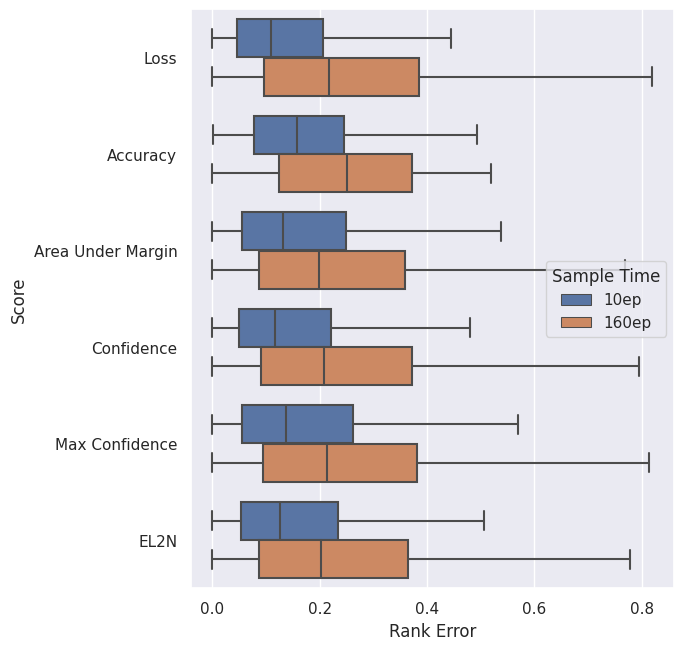

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-VGG-16_subsample_loss_rank_err.pdf


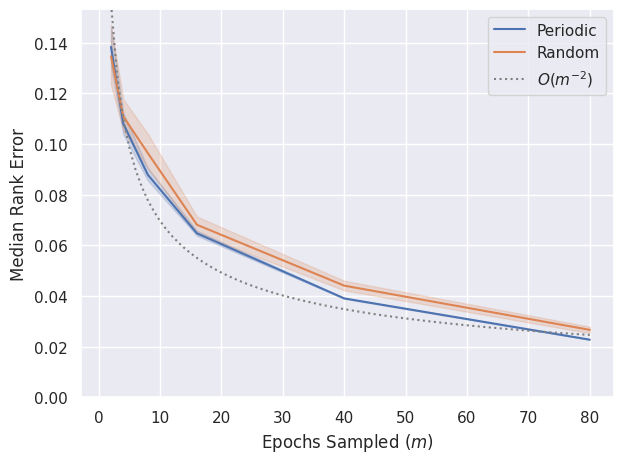

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-VGG-16_loss_std.pdf


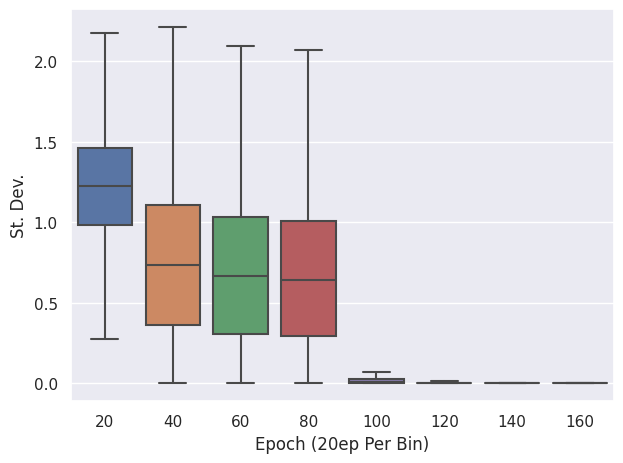

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-VGG-16_loss_rank_err.pdf


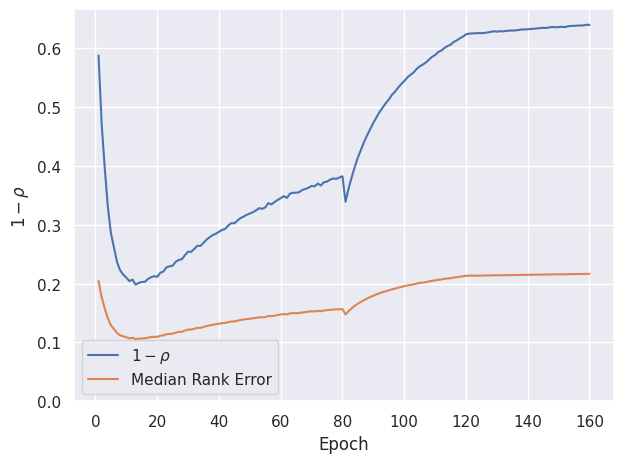

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-VGG-16_forget_rank_corr.pdf


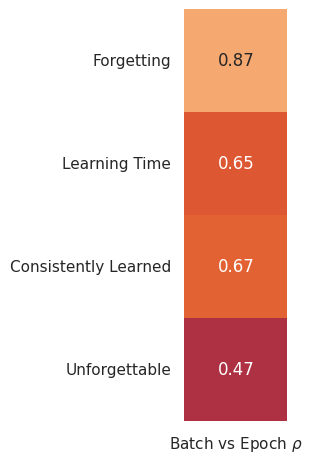

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-VGG-16_loss_rank_corr.pdf


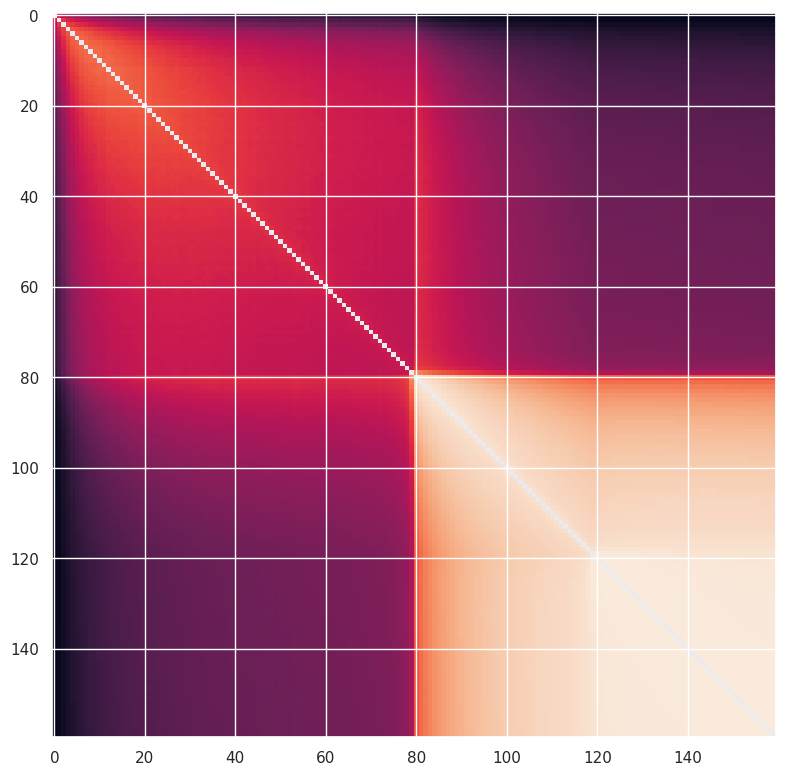

model_key                                         cifar_resnet_20
dataset_key                                              cifar100
Model                                                   ResNet-20
Dataset                                                 CIFAR-100
Task                                          CIFAR-100/ResNet-20
Parameters                                                 272474
path            ../outputs/combined/lottery_9dc2b8dfff54c4da57...
key                      lottery_9dc2b8dfff54c4da57570d7b391dcccd
n_replicates                                                  100
Name: 6, dtype: object
Grad and ckpt scores differ for ../outputs/combined/lottery_9dc2b8dfff54c4da57570d7b391dcccd/replicate_54/level_0/main/gradmetrics/grand_20ep0it.npz: n=61, atol %=0.011354232836572874
Grad and ckpt scores differ for ../outputs/combined/lottery_9dc2b8dfff54c4da57570d7b391dcccd/replicate_56/level_0/main/gradmetrics/grand_20ep0it.npz: n=50, atol %=0.01291863552310424
Grad and ckpt sc

/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/scipy/stats/stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


Saving figure to ../outputs/plots/var_epoch/CIFAR-100-ResNet-20_selected_rank_corr.pdf


<Figure size 640x480 with 0 Axes>

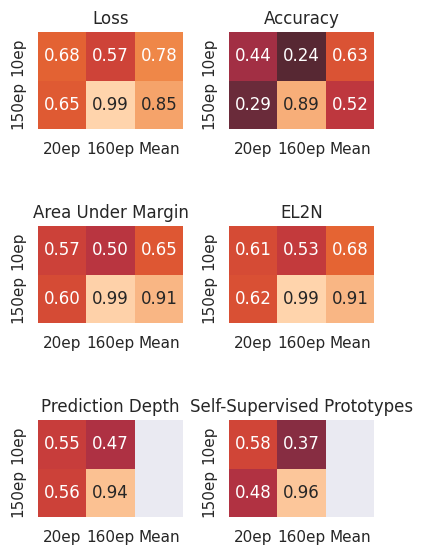

/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/scipy/stats/stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


Saving figure to ../outputs/plots/var_epoch/CIFAR-100-ResNet-20_rank_corr.pdf


<Figure size 640x480 with 0 Axes>

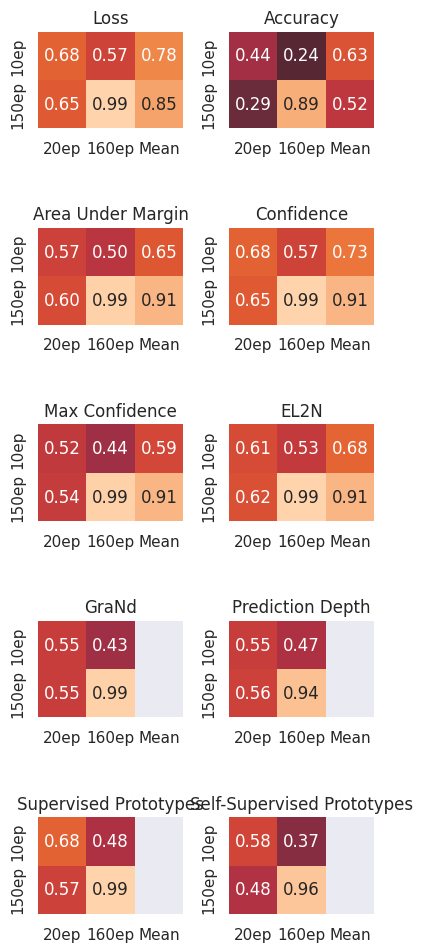

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-ResNet-20_selected_rank_err.pdf


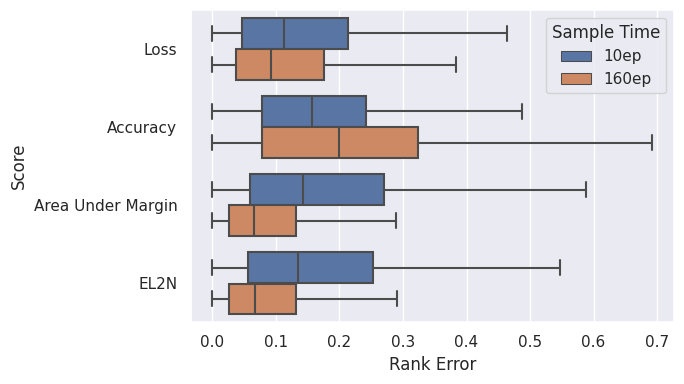

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-ResNet-20_rank_err.pdf


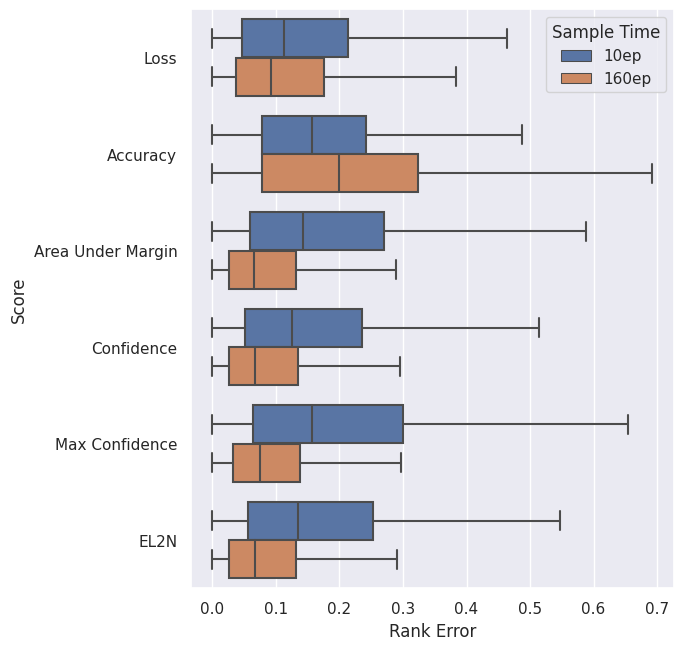

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-ResNet-20_subsample_loss_rank_err.pdf


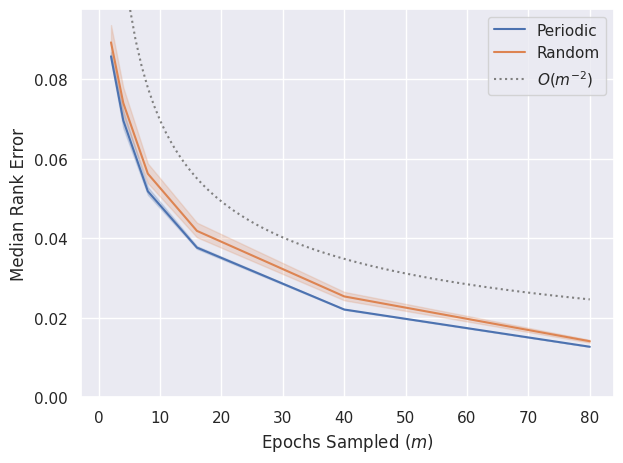

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-ResNet-20_loss_std.pdf


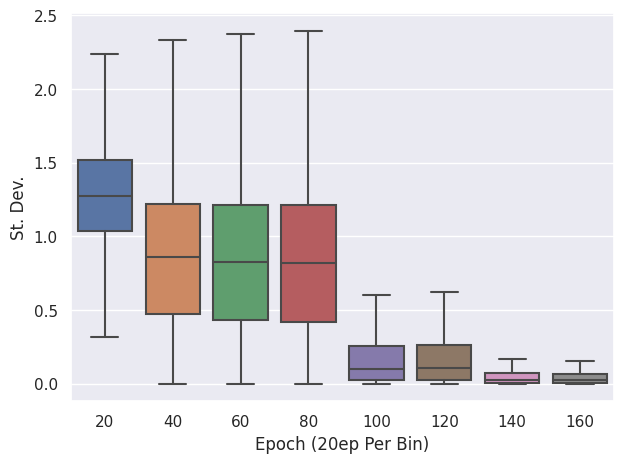

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-ResNet-20_loss_rank_err.pdf


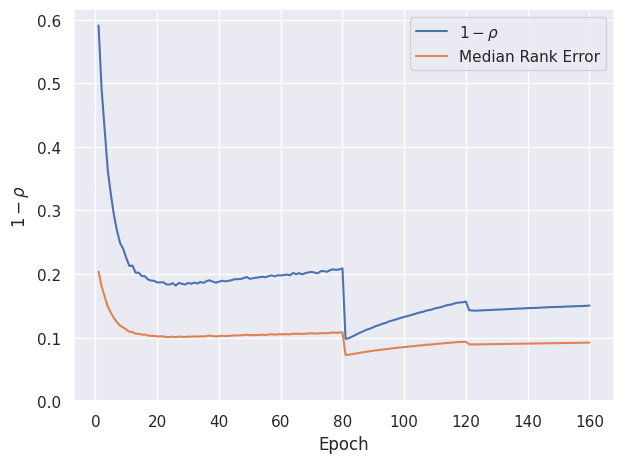

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-ResNet-20_forget_rank_corr.pdf


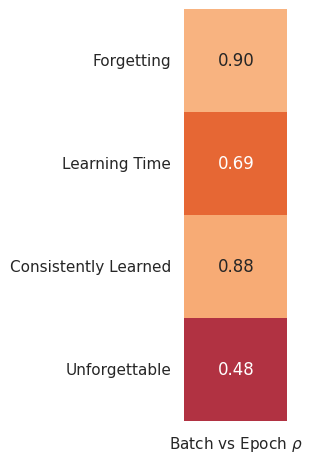

Saving figure to ../outputs/plots/var_epoch/CIFAR-100-ResNet-20_loss_rank_corr.pdf


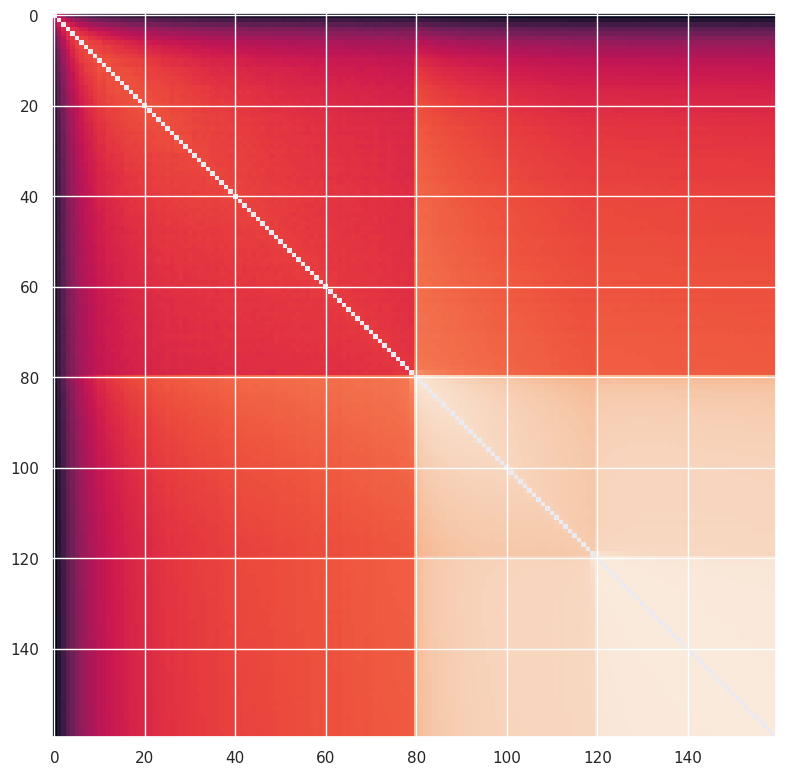

<Figure size 640x480 with 0 Axes>

In [5]:
for _, model_row in model_df.iterrows():
    print(model_row)
    sanity_checks(model_row["path"])
    task_name = model_row["Task"]

    score_df = get_score_df(model_row, n_replicates=N_RUNS)
    score_df = score_df[score_df["Epoch"] != 0]

    df = get_scores(score_df, n_examples=N_EXAMPLES, fuzz_by=0)
    training_loss = aggregate_steps(df[df["key"] == "loss"])
    df = pd.concat([df, training_loss])
    df = df[df["Type"] == ""]

    plot_training_time_correlations(df, SELECTED_SCORES, name=task_name + "_selected")
    plot_training_time_correlations(df, ALL_SCORES, name=task_name)

    plot_rank_error(df, SELECTED_SCORES, name=task_name + "_selected")
    plot_rank_error(df, ALL_SCORES, name=task_name)

    plot_subsample_loss_rank_err(df, name=task_name)

    plot_training_time_loss_std(df, name=task_name)
    plot_training_time_all_loss_rank_err(df, name=task_name)
    plot_forgetting_corr(df, name=task_name)

    plot_training_time_all_loss_corr(df, name=task_name)